# Árboles de Decisión en Machine Learning: Decision Tree
## Ejemplo con el conjunto de datos **Wine**

En este notebook vamos a construir, paso a paso, un árbol de decisión para clasificación usando el conjunto de datos **Wine**: análisis químicos de vinos italianos hechos con **3 variedades de uva** distintas.

In [19]:
# Instala las librerías necesarias (solo hace falta una vez).
# Quita el "#" de la línea de abajo para ejecutarla:
# %pip install scikit-learn pandas matplotlib

## 1. Importar librerías

- **numpy**: operaciones con números y arreglos.
- **pandas**: manejar tablas de datos (DataFrames).
- **matplotlib**: hacer gráficas.
- **zipfile**: abrir el archivo `.zip` sin tener que descomprimirlo (viene incluida en Python).
- **scikit-learn** (`sklearn`): la librería de Machine Learning. De ahí tomamos el árbol de decisión y las herramientas para evaluarlo.

In [20]:
import zipfile                         # para leer archivos dentro de un .zip
import numpy as np                     # cálculos numéricos
import pandas as pd                    # tablas de datos
import matplotlib.pyplot as plt        # gráficas
from matplotlib.colors import ListedColormap  # para elegir nuestros propios colores

from sklearn.model_selection import train_test_split      # para separar entrenamiento y prueba
from sklearn.tree import DecisionTreeClassifier           # el árbol de decisión (clasificación)
from sklearn.tree import plot_tree, export_text           # para dibujar el árbol y verlo como texto
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay  # para evaluar el modelo

# Colores lilas: uno por variedad de uva
colores = ["#E8DDF3", "#B58FD6", "#6B3FA0"]

## 2. Cargar y conocer los datos

El conjunto Wine tiene **178 vinos** de una misma región de Italia, elaborados con **3 variedades de uva** (cultivares). A cada vino se le midieron **13 compuestos químicos**:

| Variable | Significado |
|---|---|
| alcohol | grado de alcohol (% del volumen) |
| ácido málico | ácido que da sabor agrio (como a manzana verde) |
| ceniza | minerales que quedan al quemar el vino |
| alcalinidad ceniza | qué tan alcalinos son esos minerales |
| magnesio | contenido de magnesio |
| fenoles totales | compuestos que influyen en sabor, color y aroma |
| flavonoides | un tipo de fenoles; dan cuerpo, color y amargor |
| fenoles no flavonoides | el resto de los fenoles |
| proantocianinas | compuestos que dan astringencia (sensación "seca") |
| intensidad color | qué tan intenso es el color del vino |
| tono | matiz del color |
| OD280/OD315 | medida de laboratorio relacionada con las proteínas del vino |
| prolina | aminoácido presente en el vino |

El archivo `wine.data` (dentro de `wine.zip`) no trae nombres de columnas: la **primera columna** es la variedad de uva (1, 2 o 3) y las **13 siguientes** son las medidas, en el orden de la tabla. Vamos a ponerles nombres en español.

In [21]:
# Nombres de las columnas, en el mismo orden que vienen en el archivo
nombres_variables = ["alcohol", "ácido málico", "ceniza", "alcalinidad ceniza", "magnesio",
                     "fenoles totales", "flavonoides", "fenoles no flavonoides",
                     "proantocianinas", "intensidad color", "tono", "OD280/OD315", "prolina"]

# Abrimos el .zip y leemos el archivo wine.data que está adentro
with zipfile.ZipFile("wine.zip") as archivo_zip:
    with archivo_zip.open("wine.data") as archivo:
        # header=None: el archivo no tiene fila de títulos
        # names=...: le ponemos nosotros los nombres (primero la variedad y luego las 13 medidas)
        datos = pd.read_csv(archivo, header=None, names=["variedad"] + nombres_variables)

# La variedad viene como número (1, 2, 3); la cambiamos por un nombre más claro
nombres_variedades = ["Variedad 1", "Variedad 2", "Variedad 3"]
datos["variedad"] = datos["variedad"].map({1: "Variedad 1", 2: "Variedad 2", 3: "Variedad 3"})

# Mostramos las primeras 5 filas de la tabla
datos.head()

,variedad,alcohol,ácido málico,ceniza,alcalinidad ceniza,magnesio,fenoles totales,flavonoides,fenoles no flavonoides,proantocianinas,intensidad color,tono,OD280/OD315,prolina
0,Variedad 1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,Variedad 1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,Variedad 1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,Variedad 1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,Variedad 1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [22]:
# ¿Cuántos vinos hay en total y cuántas columnas?
print("Tamaño de la tabla (filas, columnas):", datos.shape)

# ¿Hay datos faltantes? (suma de celdas vacías en toda la tabla)
print("Datos faltantes:", datos.isna().sum().sum())

Tamaño de la tabla (filas, columnas): (178, 14)
Datos faltantes: 0


In [23]:
# ¿Cuántos vinos hay de cada variedad?
datos["variedad"].value_counts().sort_index()

variedad
Variedad 1    59
Variedad 2    71
Variedad 3    48
Name: count, dtype: int64

Hay 59, 71 y 48 vinos de cada variedad: el conjunto está **casi balanceado** (no hay una variedad que domine) y **no tiene datos faltantes**, así que no hace falta limpiarlo.

Veamos cómo se reparten los vinos según su **alcohol** y sus **flavonoides**:

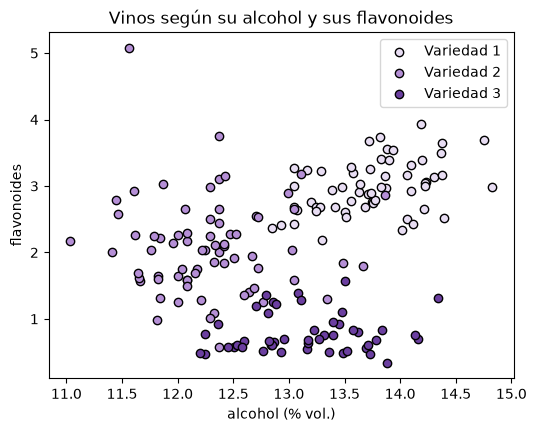

In [24]:
# Gráfica de dispersión: cada punto es un vino, el color indica su variedad
plt.figure(figsize=(6, 4.5))
for i, variedad in enumerate(nombres_variedades):
    # Nos quedamos solo con los vinos de esta variedad
    grupo = datos[datos["variedad"] == variedad]
    plt.scatter(grupo["alcohol"], grupo["flavonoides"],
                color=colores[i], edgecolor="black", label=variedad)

plt.xlabel("alcohol (% vol.)")
plt.ylabel("flavonoides")
plt.title("Vinos según su alcohol y sus flavonoides")
plt.legend()
plt.show()

Se ven tres "nubes" bastante separadas:
- **Variedad 1**: mucho alcohol y muchos flavonoides (arriba a la derecha).
- **Variedad 2**: poco alcohol (a la izquierda).
- **Variedad 3**: pocos flavonoides (abajo).

Las nubes se tocan un poco en las orillas, así que el árbol no será perfecto, pero sí debería acertar casi siempre.

## 3. Elegir las variables

En aprendizaje supervisado separamos:
- **X** → las variables de entrada (lo que el modelo puede "ver").
- **y** → la variable objetivo (la respuesta que queremos predecir: la variedad de uva).

Para que sea sencillo, y para poder **dibujar el árbol como un mapa en 2D**, usamos solo dos variables: **alcohol** y **flavonoides**. Son las dos que, juntas, mejor separan las tres variedades. (Al final del notebook hay un extra con las 13 variables.)

In [25]:
# Variables de entrada: solo alcohol y flavonoides
variables = ["alcohol", "flavonoides"]
X = datos[variables]

# Variable objetivo: la variedad de cada vino
y = datos["variedad"]

# Revisamos el tamaño: 178 vinos (filas) y 2 variables (columnas)
print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (178, 2)
Tamaño de y: (178,)


## 4. Separar datos de entrenamiento y de prueba

Si evaluamos al modelo con los mismos vinos con los que aprendió, sería como presentar un examen con las respuestas en la mano. Por eso dividimos los datos:
- **Entrenamiento (70 %)**: con estos vinos el árbol aprende sus preguntas.
- **Prueba (30 %)**: vinos que el árbol **nunca ha visto**; sirven para medir qué tan bien funciona con datos nuevos.

`stratify=y` hace que en ambos grupos haya la misma proporción de cada variedad, y `random_state=14` es una semilla: fija qué vinos caen en cada grupo, para que la división sea siempre la misma cada vez que corremos el notebook.

In [26]:
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y,
    test_size=0.3,      # 30 % de los vinos se guardan para la prueba
    stratify=y,         # misma proporción de variedades en ambos grupos
    random_state=14,    # semilla: fija qué vinos van a cada grupo (resultado reproducible)
)

print("Vinos para entrenar:", len(X_entrena))
print("Vinos para probar:  ", len(X_prueba))

Vinos para entrenar: 124
Vinos para probar:   54


## 5. ¿Qué tan "revuelto" está un grupo? El índice de Gini a mano

Antes de dejar que scikit-learn haga todo, calculemos nosotros mismos lo que el árbol usa para elegir sus preguntas.

La **impureza** de un grupo se mide con el **índice de Gini**:

$$G = 1 - \sum_k p_k^2$$

donde $p_k$ es la proporción de la clase $k$ en el grupo.
- Grupo **puro** (todos los vinos de la misma variedad) ⇒ $G = 0$.
- Grupo más mezclado ⇒ $G$ más grande.

In [27]:
def gini(etiquetas):
    # Proporción de cada clase dentro del grupo (p_k)
    proporciones = etiquetas.value_counts(normalize=True)
    # Fórmula del índice de Gini: G = 1 - suma(p_k^2)
    return 1 - np.sum(proporciones ** 2)

# Gini de TODOS los vinos (59, 71 y 48 de cada variedad)
print("Gini de todos los datos:", round(gini(y), 3))

Gini de todos los datos: 0.658


Con las tres variedades mezcladas, $G \approx 0.658$. Es casi el máximo posible con 3 clases ($0.667$, que se daría si las tres tuvieran exactamente la misma cantidad).

Ahora probamos una pregunta: **¿alcohol ≤ 12.78?** Esta pregunta corta los datos en dos grupos. Calculamos el Gini de cada uno:

In [28]:
# Hacemos la pregunta a cada vino: True = "sí", False = "no"
respuesta = datos["alcohol"] <= 12.78

# Separamos las variedades en dos grupos según la respuesta
grupo_si = y[respuesta]     # vinos que respondieron "sí" (poco alcohol)
grupo_no = y[~respuesta]    # vinos que respondieron "no" (~ significa "lo contrario")

# dict(...) convierte el conteo en un diccionario fácil de leer
print("Grupo 'sí':", len(grupo_si), "vinos →", dict(grupo_si.value_counts().sort_index()))
print("Grupo 'no':", len(grupo_no), "vinos →", dict(grupo_no.value_counts().sort_index()))
print()
print("Gini grupo 'sí':", round(gini(grupo_si), 3))
print("Gini grupo 'no':", round(gini(grupo_no), 3))

Grupo 'sí': 73 vinos → {'Variedad 2': np.int64(62), 'Variedad 3': np.int64(11)}
Grupo 'no': 105 vinos → {'Variedad 1': np.int64(59), 'Variedad 2': np.int64(9), 'Variedad 3': np.int64(37)}

Gini grupo 'sí': 0.256
Gini grupo 'no': 0.553


- El grupo **"sí"** (poco alcohol) quedó dominado por la **Variedad 2** (62 de 73 vinos) y **no tiene ningún** vino de la Variedad 1.
- El grupo **"no"** (mucho alcohol) tiene **todos** los vinos de la Variedad 1 y la mayoría de la Variedad 3.

Ningún grupo quedó puro, pero el grupo "sí" está **mucho menos revuelto** que el original ($G \approx 0.256$ frente a $0.658$).

### ¿Fue una buena pregunta? La ganancia

Comparamos el desorden **antes** y **después** del corte:

$$\text{Ganancia} = \text{impureza antes} - \text{impureza después}$$

La impureza "después" es el **promedio de los dos grupos, ponderado por su tamaño** (un grupo con más vinos pesa más).

In [29]:
n_total = len(y)  # número total de vinos

# Impureza antes del corte
gini_antes = gini(y)

# Impureza después: promedio ponderado por el tamaño de cada grupo
gini_despues = (len(grupo_si) / n_total) * gini(grupo_si) + (len(grupo_no) / n_total) * gini(grupo_no)

# Ganancia = antes - después
ganancia = gini_antes - gini_despues

print("Impureza antes:  ", round(gini_antes, 3))
print("Impureza después:", round(gini_despues, 3))
print("Ganancia:        ", round(ganancia, 3))

Impureza antes:   0.658
Impureza después: 0.431
Ganancia:         0.227


La pregunta redujo el desorden de forma importante. Comparémosla con una pregunta **mala**, por ejemplo sobre el magnesio:

In [30]:
def ganancia_de_pregunta(variable, corte):
    # Divide los vinos con la pregunta "¿variable <= corte?" y calcula la ganancia
    respuesta = datos[variable] <= corte
    si, no = y[respuesta], y[~respuesta]
    despues = (len(si) / n_total) * gini(si) + (len(no) / n_total) * gini(no)
    return gini(y) - despues

print("Ganancia de '¿alcohol ≤ 12.78?':", round(ganancia_de_pregunta("alcohol", 12.78), 3))
print("Ganancia de '¿magnesio ≤ 100?':  ", round(ganancia_de_pregunta("magnesio", 100), 3))

Ganancia de '¿alcohol ≤ 12.78?': 0.227
Ganancia de '¿magnesio ≤ 100?':   0.055


La pregunta sobre el magnesio casi no reduce el desorden: **no sirve** para distinguir variedades.

El árbol hace exactamente esto, pero con **muchas preguntas posibles** (todas las variables y muchos valores de corte), y se queda con la de **mayor ganancia**. Luego repite lo mismo dentro de cada grupo nuevo. Es una estrategia **codiciosa** (*greedy*): en cada paso elige lo mejor en ese momento.

## 6. Entrenar el árbol

Ahora dejamos que scikit-learn construya el árbol. Le damos tres indicaciones:
- `criterion="gini"`: usar el índice de Gini para medir la impureza (como hicimos arriba).
- `max_depth=2`: el árbol puede hacer **como máximo 2 niveles de preguntas**. Esto es *limitar el crecimiento* para evitar que memorice los datos.
- `random_state=42`: para que el resultado sea siempre el mismo.

El método `.fit()` es donde el modelo **aprende** a partir de los datos de entrenamiento.

In [45]:
# Creamos el árbol (todavía no sabe nada)
arbol = DecisionTreeClassifier(criterion="gini", max_depth=2, random_state=42)

# Lo entrenamos: aquí descubre las mejores preguntas a partir de los datos
arbol.fit(X_entrena, y_entrena)

print("¡Árbol entrenado!")
print("Profundidad:", arbol.get_depth())
print("Número de hojas:", arbol.get_n_leaves())

¡Árbol entrenado!
Profundidad: 2
Número de hojas: 4


## 7. El árbol como diagrama

La forma más intuitiva de ver el árbol: cada caja es una **pregunta** y cada hoja da una **variedad**.

En cada caja aparece:
- la **pregunta** (solo en los nodos que no son hojas),
- `gini`: la impureza del grupo que llegó ahí,
- `samples`: cuántos vinos llegaron a ese nodo,
- `value`: cuántos vinos hay de cada variedad,
- `class`: la variedad más común (la predicción si el recorrido terminara ahí).

Las ramas hacia la **izquierda** son la respuesta **"sí"** (True) y hacia la **derecha** **"no"** (False).

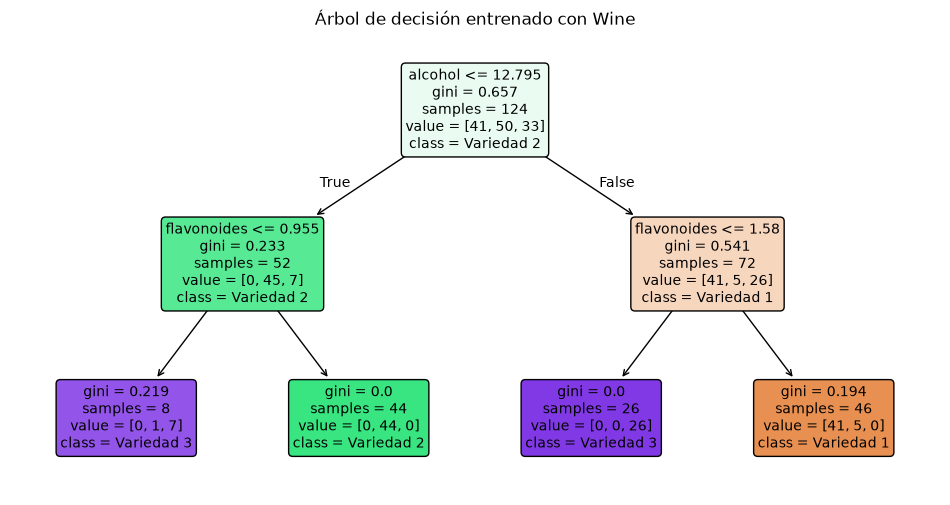

In [46]:
plt.figure(figsize=(12, 6))
plot_tree(
    arbol,
    feature_names=variables,             # nombres de las variables en las preguntas
    class_names=arbol.classes_,          # nombres de las variedades en las hojas
    filled=True,                         # colorea cada caja según la variedad dominante
    rounded=True,                        # esquinas redondeadas
    fontsize=10,
)
plt.title("Árbol de decisión entrenado con Wine")
plt.show()

También podemos ver el árbol como texto, que se lee como una lista de reglas "si… entonces…":

In [33]:
# export_text escribe el árbol como reglas de texto
print(export_text(arbol, feature_names=variables))

|--- alcohol <= 12.80
|   |--- flavonoides <= 0.96
|   |   |--- class: Variedad 3
|   |--- flavonoides >  0.96
|   |   |--- class: Variedad 2
|--- alcohol >  12.80
|   |--- flavonoides <= 1.58
|   |   |--- class: Variedad 3
|   |--- flavonoides >  1.58
|   |   |--- class: Variedad 1



El árbol encontró por sí solo una regla muy razonable:
1. **¿alcohol ≤ 12.80?** (casi el mismo corte que probamos a mano).
2. Luego, en cada lado, pregunta por los **flavonoides**:
   - Con poco alcohol: pocos flavonoides ⇒ **Variedad 3**; si no ⇒ **Variedad 2**.
   - Con mucho alcohol: pocos flavonoides ⇒ **Variedad 3**; si no ⇒ **Variedad 1**.

Observa que la **Variedad 3 aparece en dos hojas**: su rasgo distintivo son los **pocos flavonoides**, sin importar el alcohol. Un mismo resultado puede alcanzarse por caminos distintos del árbol.

> **Nota:** los valores de corte dependen de qué vinos se usaron para entrenar. Si cambias la semilla `random_state` de la sección 4, los cortes pueden moverse un poco, porque el árbol solo ve el 70 % de los vinos.

## 8. Hacer predicciones

Un dato nuevo entra por la raíz y **baja respondiendo cada pregunta** hasta llegar a una hoja. A este recorrido se le llama *inference path*.

Probemos con tres vinos inventados:

In [34]:
# Tres vinos nuevos que el árbol nunca ha visto: [alcohol, flavonoides]
vinos_nuevos = pd.DataFrame(
    [[13.8, 3.0],    # mucho alcohol y muchos flavonoides
     [12.2, 2.0],    # poco alcohol
     [13.2, 0.7]],   # pocos flavonoides
    columns=variables,
)

# .predict() recorre el árbol para cada vino y devuelve la variedad de la hoja
predicciones = arbol.predict(vinos_nuevos)

# Mostramos el resultado de cada vino
for i in range(len(vinos_nuevos)):
    alcohol, flavonoides = vinos_nuevos.iloc[i]
    print(f"Vino con {alcohol} % de alcohol y {flavonoides} de flavonoides → {predicciones[i]}")

Vino con 13.8 % de alcohol y 3.0 de flavonoides → Variedad 1
Vino con 12.2 % de alcohol y 2.0 de flavonoides → Variedad 2
Vino con 13.2 % de alcohol y 0.7 de flavonoides → Variedad 3


El siguiente código imprime el **recorrido** de cada vino por el árbol, pregunta por pregunta:

In [35]:
# Información interna del árbol
variable_de_nodo = arbol.tree_.feature    # qué variable pregunta cada nodo
umbral_de_nodo = arbol.tree_.threshold    # el valor de corte de cada nodo

# decision_path nos dice por qué nodos pasó cada vino
caminos = arbol.decision_path(vinos_nuevos)
hojas = arbol.apply(vinos_nuevos)         # la hoja final de cada vino

for i in range(len(vinos_nuevos)):
    print(f"Vino {i + 1}: {list(vinos_nuevos.iloc[i])}")
    # Nodos visitados por el vino i
    nodos = caminos.indices[caminos.indptr[i]:caminos.indptr[i + 1]]
    for nodo in nodos:
        if nodo == hojas[i]:
            # Llegamos a la hoja: ya no hay preguntas
            print(f"   → Hoja: {predicciones[i]}")
        else:
            nombre = variables[variable_de_nodo[nodo]]   # nombre de la variable que se pregunta
            valor = vinos_nuevos.iloc[i][nombre]         # valor de ese vino en esa variable
            umbral = umbral_de_nodo[nodo]                # valor de corte de la pregunta
            respuesta = "sí" if valor <= umbral else "no"
            print(f"   ¿{nombre} ≤ {umbral:.2f}?  ({valor} ≤ {umbral:.2f}) ⇒ {respuesta}")
    print()

Vino 1: [13.8, 3.0]
   ¿alcohol ≤ 12.80?  (13.8 ≤ 12.80) ⇒ no
   ¿flavonoides ≤ 1.58?  (3.0 ≤ 1.58) ⇒ no
   → Hoja: Variedad 1

Vino 2: [12.2, 2.0]
   ¿alcohol ≤ 12.80?  (12.2 ≤ 12.80) ⇒ sí
   ¿flavonoides ≤ 0.96?  (2.0 ≤ 0.96) ⇒ no
   → Hoja: Variedad 2

Vino 3: [13.2, 0.7]
   ¿alcohol ≤ 12.80?  (13.2 ≤ 12.80) ⇒ no
   ¿flavonoides ≤ 1.58?  (0.7 ≤ 1.58) ⇒ sí
   → Hoja: Variedad 3



Además de la variedad, el árbol puede decir **qué tan seguro está**. `predict_proba` devuelve la proporción de cada variedad entre los vinos de entrenamiento que cayeron en la misma hoja:

In [36]:
# Probabilidad de cada variedad para cada vino nuevo
probabilidades = pd.DataFrame(arbol.predict_proba(vinos_nuevos),
                              columns=arbol.classes_).round(2)
probabilidades

,Variedad 1,Variedad 2,Variedad 3
0,0.89,0.11,0.0
1,0.00,1.00,0.0
2,0.00,0.00,1.0


## 9. Evaluar el modelo

Ahora usamos los vinos de **prueba** (que el árbol nunca vio) para medir qué tan bien funciona.
- **Exactitud (accuracy)**: porcentaje de vinos clasificados correctamente.
- **Matriz de confusión**: tabla que compara la variedad **real** (filas) con la **predicha** (columnas). Los números en la diagonal son los aciertos; fuera de ella, los errores.

In [37]:
# Predecimos la variedad de los vinos de prueba
y_predicha = arbol.predict(X_prueba)

# Comparamos con la variedad real
exactitud = accuracy_score(y_prueba, y_predicha)
print(f"Exactitud en prueba: {exactitud:.2%}")

Exactitud en prueba: 88.89%


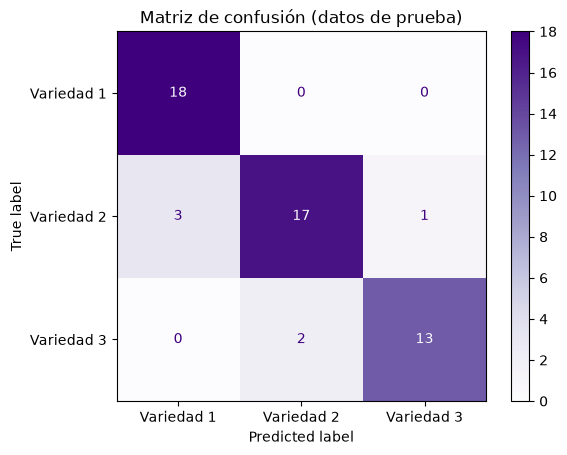

In [38]:
# Matriz de confusión: variedad real vs. variedad predicha
ConfusionMatrixDisplay.from_predictions(y_prueba, y_predicha, cmap="Purples")
plt.title("Matriz de confusión (datos de prueba)")
plt.show()

La mayoría de los vinos quedan en la diagonal. Los pocos errores ocurren con vinos que están en las **orillas** de las nubes de la gráfica de la sección 2, donde dos variedades se mezclan.

## 10. El árbol como mapa

Con dos variables podemos dibujar lo que hace el árbol sobre el plano:
- Cada pregunta es una **línea recta paralela a un eje** (por ejemplo, "alcohol = 12.80" es una línea vertical).
- El plano queda dividido en **rectángulos**.
- Cada rectángulo es **una hoja** del árbol.

Para dibujarlo, creamos una malla de muchísimos puntos, le pedimos al árbol que prediga la variedad en cada uno y pintamos cada región con su color.

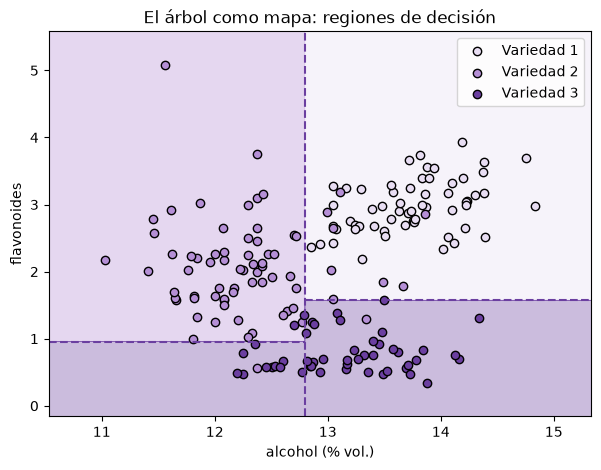

In [39]:
# 1) Creamos una malla de puntos que cubre todo el rango de los datos
x_min, x_max = X["alcohol"].min() - 0.5, X["alcohol"].max() + 0.5
y_min, y_max = X["flavonoides"].min() - 0.5, X["flavonoides"].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

# 2) Juntamos los puntos de la malla en una tabla con las mismas columnas que X
malla = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=variables)

# 3) Predecimos la variedad en cada punto y la convertimos a número (0, 1, 2) para pintar
variedad_malla = arbol.predict(malla)
numero_malla = np.array([nombres_variedades.index(v) for v in variedad_malla]).reshape(xx.shape)

# 4) Pintamos las regiones del árbol
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, numero_malla, alpha=0.35, cmap=ListedColormap(colores))

# 5) Encima, dibujamos los vinos reales
for i, variedad in enumerate(nombres_variedades):
    grupo = datos[datos["variedad"] == variedad]
    plt.scatter(grupo["alcohol"], grupo["flavonoides"],
                color=colores[i], edgecolor="black", label=variedad)

# 6) Marcamos los cortes que encontró el árbol
#    Nodo 0 = raíz (pregunta por alcohol → línea vertical)
#    children_left[0] y children_right[0] = los dos nodos de abajo (preguntan por flavonoides → líneas horizontales)
izquierdo = arbol.tree_.children_left[0]
derecho = arbol.tree_.children_right[0]
corte_raiz = arbol.tree_.threshold[0]            # corte del alcohol
corte_izq = arbol.tree_.threshold[izquierdo]     # corte de flavonoides con poco alcohol
corte_der = arbol.tree_.threshold[derecho]       # corte de flavonoides con mucho alcohol

plt.axvline(corte_raiz, color="#6B3FA0", linestyle="--")                   # línea vertical (alcohol)
plt.hlines(corte_izq, x_min, corte_raiz, color="#6B3FA0", linestyle="--")  # horizontal a la izquierda
plt.hlines(corte_der, corte_raiz, x_max, color="#6B3FA0", linestyle="--")  # horizontal a la derecha

plt.xlabel("alcohol (% vol.)")
plt.ylabel("flavonoides")
plt.title("El árbol como mapa: regiones de decisión")
plt.legend()
plt.show()

Las fronteras son "escalonadas" (formadas por rectángulos), a diferencia de un modelo lineal, que trazaría líneas diagonales. Hay **4 rectángulos**, uno por cada hoja del diagrama de la sección 7; los dos rectángulos de abajo son de la Variedad 3.

## 11. Sobreajuste: ¿qué pasa si el árbol crece sin límite?

Si el árbol pregunta sin límite, puede **memorizar** los datos de entrenamiento (incluido su ruido) y fallar con datos nuevos. A esto se le llama **sobreajuste**.

Comparemos árboles de distinta profundidad. Para cada uno medimos la exactitud con los datos de **entrenamiento** y con los de **prueba**:

In [40]:
# Probamos varias profundidades; None = sin límite (crece hasta que todas las hojas son puras)
profundidades = [1, 2, 3, 5, None]
resultados = []

for profundidad in profundidades:
    # Entrenamos un árbol con esa profundidad máxima
    modelo = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    modelo.fit(X_entrena, y_entrena)

    # Guardamos sus resultados en un diccionario (una fila de la tabla)
    resultados.append({
        "max_depth": "sin límite" if profundidad is None else profundidad,
        "profundidad real": modelo.get_depth(),
        "hojas": modelo.get_n_leaves(),
        "exactitud entrenamiento": round(modelo.score(X_entrena, y_entrena), 3),
        "exactitud prueba": round(modelo.score(X_prueba, y_prueba), 3),
    })

# Convertimos la lista de resultados en una tabla
pd.DataFrame(resultados)

,max_depth,profundidad real,hojas,exactitud entrenamiento,exactitud prueba
0,1,1,2,0.694,0.648
1,2,2,4,0.952,0.889
2,3,3,6,0.968,0.870
3,5,5,9,0.984,0.852
4,sin límite,7,11,1.000,0.852


Observa:
- Con **1 nivel** el árbol es demasiado simple: solo puede hacer una pregunta, así que no alcanza a separar las 3 variedades (le falta aprender).
- Con **2 niveles** (nuestro árbol) acierta bien tanto en entrenamiento como en prueba.
- Al dejarlo crecer más, la exactitud en **entrenamiento** sube hasta el **100 %**: el árbol se "aprende de memoria" los vinos que ya vio.
- Pero la exactitud en **prueba** **baja**: el árbol más grande generaliza peor con vinos nuevos. ¡Eso es el **sobreajuste**!

Por eso hay que controlar su tamaño: **limitar el crecimiento** (`max_depth`, `min_samples_leaf`) o **podar** el árbol (en scikit-learn, con el parámetro `ccp_alpha`).

## 12. Extra: ¿y si usamos las 13 variables?

Hasta ahora usamos solo 2 variables para poder dibujar el mapa. Veamos qué pasa si le damos al árbol **las 13 medidas químicas** y lo dejamos elegir.

In [41]:
# Ahora X tiene todas las medidas químicas
X_todas = datos[nombres_variables]

# Misma división 70/30 y misma semilla que antes
Xt_entrena, Xt_prueba, yt_entrena, yt_prueba = train_test_split(
    X_todas, y, test_size=0.3, stratify=y, random_state=14)

# Mismo tipo de árbol: profundidad máxima 2
arbol_todas = DecisionTreeClassifier(max_depth=2, random_state=42)
arbol_todas.fit(Xt_entrena, yt_entrena)

print(f"Exactitud en prueba con 13 variables: {arbol_todas.score(Xt_prueba, yt_prueba):.2%}")
print()
# Reglas que eligió el árbol
print(export_text(arbol_todas, feature_names=nombres_variables))

Exactitud en prueba con 13 variables: 79.63%

|--- intensidad color <= 3.95
|   |--- fenoles totales <= 1.42
|   |   |--- class: Variedad 3
|   |--- fenoles totales >  1.42
|   |   |--- class: Variedad 2
|--- intensidad color >  3.95
|   |--- flavonoides <= 1.58
|   |   |--- class: Variedad 3
|   |--- flavonoides >  1.58
|   |   |--- class: Variedad 1



¡Sorpresa! Con 13 variables el árbol acierta **menos** (alrededor de 80 %) que con solo alcohol y flavonoides (alrededor de 89 %). ¿Por qué?

- El árbol es **codicioso**: en la raíz eligió la **intensidad del color**, porque era la mejor pregunta **para los vinos de entrenamiento**, aunque luego no resultó la mejor para los vinos nuevos.
- El conjunto de prueba es pequeño (54 vinos): cada vino mal clasificado baja casi 2 puntos la exactitud.
- Los árboles son **inestables**: con otra semilla en la división de los datos, el resultado podría ser distinto (y las 13 variables podrían ganar).

**Lección:** más variables **no garantizan** un mejor modelo. Por eso conviene evaluar siempre con datos de prueba.

La **importancia de cada variable** indica cuánto contribuyó a reducir la impureza en todo el árbol (todas suman 1). Las variables que el árbol nunca usó tienen importancia 0.

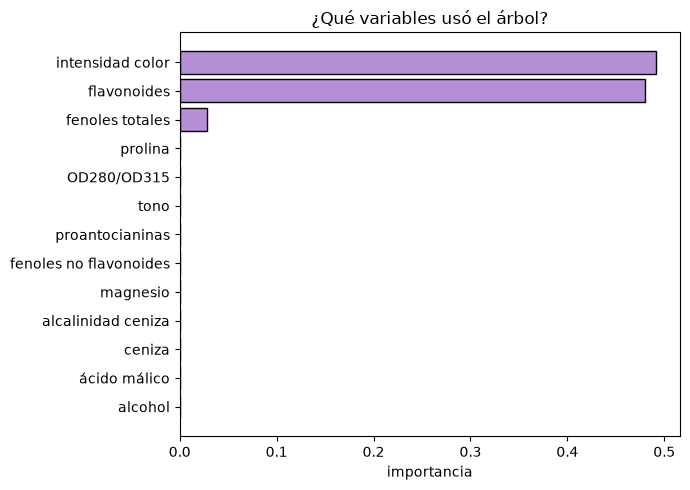

In [42]:
# Importancia de cada variable, ordenada de mayor a menor
importancias = pd.Series(arbol_todas.feature_importances_, index=nombres_variables).sort_values()

plt.figure(figsize=(7, 5))
plt.barh(importancias.index, importancias.values, color="#B58FD6", edgecolor="black")
plt.xlabel("importancia")
plt.title("¿Qué variables usó el árbol?")
plt.tight_layout()
plt.show()

Con todas las variables, el árbol escoge por sí solo las que le parecen más útiles e **ignora las demás**: hace una especie de **selección de variables** automática. Aun así, como vimos, su elección no siempre es la mejor para datos nuevos.

## 13. Resumen

- Un árbol de decisión aprende **preguntas de sí o no** que separan los datos en grupos cada vez **más puros**.
- Para elegir cada pregunta, prueba muchas opciones y se queda con la de **mayor ganancia** (la que más reduce el índice de Gini).
- Con el conjunto Wine, un árbol de solo **2 niveles** usando **alcohol** y **flavonoides** distingue las tres variedades de uva con buena exactitud.
- Es fácil de **interpretar**: se puede ver como diagrama, como reglas de texto o como mapa de regiones.
- Hay que **controlar su tamaño** para que no memorice los datos (sobreajuste).
- Más variables no siempre significan un mejor árbol: lo que importa es cómo funciona con **datos nuevos**.

## Referencias

1. scikit-learn developers, "1.10. Decision Trees," *scikit-learn User Guide*. https://scikit-learn.org/stable/modules/tree.html
2. Google for Developers, "Decision Forests," *Machine Learning course*. https://developers.google.com/machine-learning/decision-forests
3. E. Kavlakoglu, "What is a Decision Tree?," *IBM Think*, 2021. https://www.ibm.com/think/topics/decision-trees
4. G. James, D. Witten, T. Hastie, R. Tibshirani y J. Taylor, *An Introduction to Statistical Learning: with Applications in Python*. Springer, 2023. Cap. 8.
5. scikit-learn developers, "DecisionTreeClassifier," *scikit-learn API Reference*. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
6. M. Forina et al., *Wine* [conjunto de datos], UCI Machine Learning Repository, 1991. https://archive.ics.uci.edu/dataset/109/wine